# File

In [62]:
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("ML_Ready_Primary.csv") # ETO YUNG GINAMIT KONG CSV YA CHINECK Q NA
X = df.drop('HIV_Status', axis=1)
y = df['HIV_Status']

In [63]:
df.head(10)

,Province,LGU_Classification,Sex,Age_Group,Transmission,Healthcare_Access_Friction,Civil_Status,OFW_Status,Chemsex_Engagement,Alcohol_Sex_Risk,PrEP_Awareness,Transactional_Sex,STI_BBV_CoInfection_Any,HIV_Status
0,Batangas,Municipality,Female,<15,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
1,Batangas,Municipality,Male,15-24,Male to Female Sex,2,Single,No,No,No,No,No TS,No,Reactive
2,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,No,No,Yes,No TS,Yes,Reactive
3,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,No,No,No,No TS,Yes,Reactive
4,Batangas,Municipality,Male,15-24,Male to Male Sex,2,Single,No,Yes,No,Yes,No TS,No,Reactive
5,Batangas,Municipality,Male,15-24,Male to Male/Female Sex,2,Single,No,No,Yes,Yes,Both,No,Reactive
6,Batangas,Municipality,Male,25-34,Male to Female Sex,2,Common-Law,No,No,No,No,No TS,No,Reactive
7,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,No,Yes,No TS,No,Reactive
8,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,No,No,No TS,No,Reactive
9,Batangas,Municipality,Male,25-34,Male to Male Sex,2,Single,No,No,Yes,Yes,Paid for sex,Yes,Reactive


# Preprocessing

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import re

categorical_features = [
    'Province', 'LGU_Classification', 'Sex', 'Age_Group', 'Transmission',
    'Healthcare_Access_Friction', 'Civil_Status', 'OFW_Status', 'Chemsex_Engagement',
    'Alcohol_Sex_Risk', 'PrEP_Awareness', 'Transactional_Sex', 'STI_BBV_CoInfection_Any'
]

# 1. Split Data 4 ways FIRST (Prevents Data Leakage)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

X_train, X_val_temp, y_train, y_val_temp = train_test_split(
    X_temp, y_temp, stratify=y_temp, test_size=0.25, random_state=42
)

# Split Validation in half (10% Stop, 10% Threshold)
X_val_stop, X_val_thresh, y_val_stop, y_val_thresh = train_test_split(
    X_val_temp, y_val_temp, stratify=y_val_temp, test_size=0.5, random_state=42
)

# 2. Setup the Explicit One-Hot Encoder
# sparse_output=False ensures we get a dense matrix back, which XGBoost prefers
# handle_unknown='ignore' prevents crashes if the test set has a rare category the train set missed
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Leaves any numerical columns untouched
)

# 3. Fit on Training ONLY, then Transform all sets
X_train_arr = preprocessor.fit_transform(X_train)
X_val_stop_arr = preprocessor.transform(X_val_stop)
X_val_thresh_arr = preprocessor.transform(X_val_thresh)
X_test_arr = preprocessor.transform(X_test)

# 4. Get the expanded feature names, CLEAN THEM, and cast back to Pandas
feature_names = preprocessor.get_feature_names_out()

# Clean forbidden XGBoost characters
safe_feature_names = [re.sub(r'[\[\]<]', '_', name) for name in feature_names]

X_train_processed = pd.DataFrame(X_train_arr, columns=safe_feature_names, index=X_train.index)
X_val_stop_processed = pd.DataFrame(X_val_stop_arr, columns=safe_feature_names, index=X_val_stop.index)
X_val_thresh_processed = pd.DataFrame(X_val_thresh_arr, columns=safe_feature_names, index=X_val_thresh.index)
X_test_processed = pd.DataFrame(X_test_arr, columns=safe_feature_names, index=X_test.index)
# 5. Map Targets
mapping = {'Non-Reactive': 0, 'Reactive': 1}
y_train_processed = y_train.map(mapping)
y_val_stop_processed = y_val_stop.map(mapping)
y_val_thresh_processed = y_val_thresh.map(mapping)
y_test_processed = y_test.map(mapping)

# 6. Calculate the scale_pos_weight
neg_count = (y_train_processed == 0).sum()
pos_count = (y_train_processed == 1).sum()
spw = neg_count / pos_count
print(f"Calculated scale_pos_weight for XGBoost: {spw:.2f}")
print(f"Total Features after One-Hot Encoding: {X_train_processed.shape[1]}")

Calculated scale_pos_weight for XGBoost: 12.12
Total Features after One-Hot Encoding: 42


 # MODEL AND THRESHOLD MOVING

In [67]:
import xgboost as xgb
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (
    f1_score, precision_score, recall_score, precision_recall_curve,
    confusion_matrix, balanced_accuracy_score, brier_score_loss,
    average_precision_score, classification_report
)
import numpy as np

param_grid_xgb = {
    'max_depth': [3, 5, 7],         
    'learning_rate': [0.01, 0.05, 0.1]  
}

best_val_auprc = -1
best_params_xgb = None
best_xgb_model = None

print("\nCommencing Grid Search using Validation Set & Early Stopping...")

for params in ParameterGrid(param_grid_xgb):
    xgb_model = xgb.XGBClassifier(
        **params,
        n_estimators=500,
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='aucpr',        
        tree_method="hist",            
        early_stopping_rounds=20,  
        n_jobs=-1
    )
    
    # Train using the STOPPING split (Updated to use the explicitly One-Hot Encoded data)
    xgb_model.fit(
        X_train_processed, 
        y_train_processed,
        eval_set=[(X_val_stop_processed, y_val_stop_processed)],
        verbose=False
    )
    
    # Evaluate strictly on the STOPPING split
    y_val_probs = xgb_model.predict_proba(X_val_stop_processed)[:, 1]
    val_auprc = average_precision_score(y_val_stop_processed, y_val_probs)
    
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        best_params_xgb = params
        best_xgb_model = xgb_model

optimal_trees = best_xgb_model.best_iteration
print(f"\nBest Parameters: {best_params_xgb} (Stopped at {optimal_trees} trees)")
print(f"Best Validation AUPRC: {best_val_auprc:.4f}")

# ---------------------------------------------------------
# STEP 2: FIND GOLDEN THRESHOLD ON UNSEEN THRESHOLD SPLIT
# ---------------------------------------------------------
xgb_probs_thresh = best_xgb_model.predict_proba(X_val_thresh_processed)[:, 1]

precisions_val, recalls_val, thresholds_val = precision_recall_curve(y_val_thresh_processed, xgb_probs_thresh)
f1_scores_val = 2 * (precisions_val * recalls_val) / (precisions_val + recalls_val + 1e-8)

best_idx = np.argmax(f1_scores_val[:-1]) 
miku_threshold = thresholds_val[best_idx]
print(f"\nGolden Threshold (Found on Val Thresh Set): {miku_threshold:.4f}")

# ---------------------------------------------------------
# STEP 3: EVALUATE THIS THRESHOLD ON THE *TEST* SET
# ---------------------------------------------------------
xgb_probs_test = best_xgb_model.predict_proba(X_test_processed)[:, 1]

optimal_preds_test = (xgb_probs_test >= miku_threshold).astype(int)
default_preds_test = (xgb_probs_test >= 0.5).astype(int)

# Specificity
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test_processed, optimal_preds_test).ravel()
specificity_optimal = tn_opt / (tn_opt + fp_opt)

tn_def, fp_def, fn_def, tp_def = confusion_matrix(y_test_processed, default_preds_test).ravel()
specificity_default = tn_def / (tn_def + fp_def)

# Balanced Accuracy & Brier Score
bal_acc_optimal = balanced_accuracy_score(y_test_processed, optimal_preds_test)
bal_acc_default = balanced_accuracy_score(y_test_processed, default_preds_test)
brier_test = brier_score_loss(y_test_processed, xgb_probs_test)
auprc_test = average_precision_score(y_test_processed, xgb_probs_test)

print("\n--- FINAL TEST SET PERFORMANCE COMPARISON ---")
print(f"{'Metric':<20} | {'Default (0.5)':<15} | {'Optimized ('+str(round(miku_threshold,2))+')':<15}")
print("-" * 60)
print(f"{'F1-Score':<20} | {f1_score(y_test_processed, default_preds_test):<15.4f} | {f1_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Precision':<20} | {precision_score(y_test_processed, default_preds_test, zero_division=0):<15.4f} | {precision_score(y_test_processed, optimal_preds_test, zero_division=0):<15.4f}")
print(f"{'Recall':<20} | {recall_score(y_test_processed, default_preds_test):<15.4f} | {recall_score(y_test_processed, optimal_preds_test):<15.4f}")
print(f"{'Specificity':<20} | {specificity_default:<15.4f} | {specificity_optimal:<15.4f}")
print(f"{'Balanced Accuracy':<20} | {bal_acc_default:<15.4f} | {bal_acc_optimal:<15.4f}")
print("-" * 60)
print(f"Overall AUPRC (Test Set Power):   {auprc_test:.4f}")
print(f"Overall Brier Score (Calibration): {brier_test:.4f}")


Commencing Grid Search using Validation Set & Early Stopping...

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3} (Stopped at 83 trees)
Best Validation AUPRC: 0.1483

Golden Threshold (Found on Val Thresh Set): 0.5683

--- FINAL TEST SET PERFORMANCE COMPARISON ---
Metric               | Default (0.5)   | Optimized (0.57)
------------------------------------------------------------
F1-Score             | 0.1976          | 0.2009         
Precision            | 0.1245          | 0.1302         
Recall               | 0.4782          | 0.4406         
Specificity          | 0.7227          | 0.7571         
Balanced Accuracy    | 0.6005          | 0.5989         
------------------------------------------------------------
Overall AUPRC (Test Set Power):   0.1379
Overall Brier Score (Calibration): 0.2320


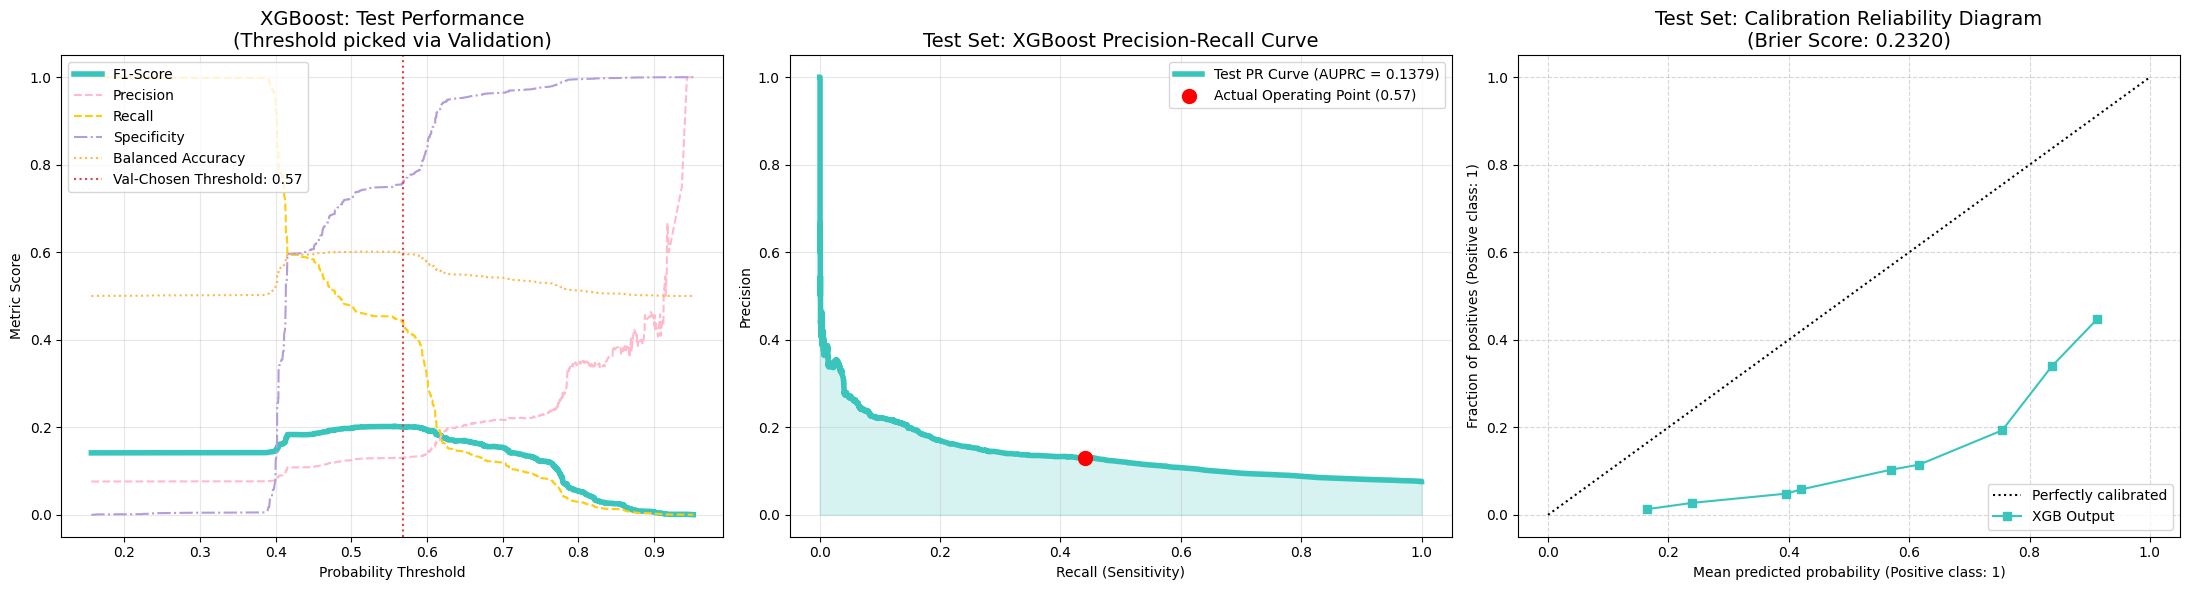

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
from sklearn.calibration import CalibrationDisplay
# ---------------------------------------------------------
# STEP 4: PREPARE PLOTTING METRICS (ON TEST SET)
# ---------------------------------------------------------
precision_xgb, recall_xgb, pr_thresholds_xgb = precision_recall_curve(y_test_processed, xgb_probs_test)
test_f1s = 2 * (precision_xgb * recall_xgb) / (precision_xgb + recall_xgb + 1e-8)
auprc_xgb = average_precision_score(y_test_processed, xgb_probs_test)

# Calculate Specificity and Balanced Accuracy across all thresholds for Plot 1
test_specificity = []
test_bal_acc = []

for t in pr_thresholds_xgb:
    preds = (xgb_probs_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_processed, preds).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0 
    
    test_specificity.append(spec)
    test_bal_acc.append((spec + sens) / 2)

# ---------------------------------------------------------
# STEP 5: PLOT ALL 3 GRAPHS (1x3 GRID)
# ---------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

# --- PLOT 1: Threshold vs Metrics ---
ax1.plot(pr_thresholds_xgb, test_f1s[:-1], label='F1-Score', color='#39C5BB', linewidth=4)
ax1.plot(pr_thresholds_xgb, precision_xgb[:-1], label='Precision', color='#FFBACC', linestyle='--')
ax1.plot(pr_thresholds_xgb, recall_xgb[:-1], label='Recall', color='#FFCC11', linestyle='--')
ax1.plot(pr_thresholds_xgb, test_specificity, label='Specificity', color='#B39DDB', linestyle='-.')
ax1.plot(pr_thresholds_xgb, test_bal_acc, label='Balanced Accuracy', color='#FFB74D', linestyle=':')

ax1.axvline(miku_threshold, color='#DD4444', linestyle=':', 
            label=f'Val-Chosen Threshold: {miku_threshold:.2f}')

ax1.set_title("XGBoost: Test Performance\n(Threshold picked via Validation)", fontsize=14)
ax1.set_xlabel("Probability Threshold")
ax1.set_ylabel("Metric Score")
ax1.legend()
ax1.grid(alpha=0.3)

# --- PLOT 2: Precision-Recall Curve ---
ax2.plot(recall_xgb, precision_xgb, color='#39C5BB', linewidth=4, label=f'Test PR Curve (AUPRC = {auprc_xgb:.4f})')
ax2.fill_between(recall_xgb, 0, precision_xgb, color='#39C5BB', alpha=0.2)

idx_xgb = np.argmin(np.abs(pr_thresholds_xgb - miku_threshold))
ax2.scatter(recall_xgb[idx_xgb], precision_xgb[idx_xgb], color='red', s=100, zorder=5, label=f'Actual Operating Point ({miku_threshold:.2f})')

ax2.set_title("Test Set: XGBoost Precision-Recall Curve", fontsize=14)
ax2.set_xlabel("Recall (Sensitivity)")
ax2.set_ylabel("Precision")
ax2.legend()
ax2.grid(alpha=0.3)

# --- PLOT 3: Calibration Curve ---
CalibrationDisplay.from_predictions(
    y_test_processed, 
    xgb_probs_test, 
    n_bins=10, 
    name="XGB Output",
    ax=ax3,
    color='#39C5BB'
)
ax3.set_title(f"Test Set: Calibration Reliability Diagram\n(Brier Score: {brier_test:.4f})", fontsize=14)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# SHAP

In [78]:
import shap
import pandas as pd
import numpy as np

# 1. Initialize the Tree Explainer for your XGBoost model
explainer_xgb = shap.TreeExplainer(best_xgb_model)

# Calculate SHAP values. 
# We are now using X_test_processed, which contains the exact explicit 1s and 0s
shap_vals_xgb = explainer_xgb.shap_values(X_test_processed)

# XGBoost typically returns a 2D array, but safely handle lists just in case
if isinstance(shap_vals_xgb, list):
    shap_raw_xgb = shap_vals_xgb[1]
else:
    shap_raw_xgb = shap_vals_xgb

# 2. Extract feature names safely
# Since X_test_processed is already a beautifully formatted DataFrame, this is easy
feature_names = X_test_processed.columns

# Put them in a DataFrame for easy manipulation
shap_df_xgb = pd.DataFrame(shap_raw_xgb, columns=feature_names)

# 3. Define the exact prefixes of your multiplied/One-Hot Encoded columns
categorical_prefixes = [
    'cat__Province', 'cat__LGU_Classification', 'cat__Sex', 'cat__Age_Group', 'cat__Transmission',
    'cat__Healthcare_Access_Friction', 'cat__Civil_Status', 'cat__OFW_Status', 'cat__Chemsex_Engagement',
    'cat__Alcohol_Sex_Risk', 'cat__PrEP_Awareness', 'cat__Transactional_Sex', 'cat__STI_BBV_CoInfection_Any'
]

# 4. Stitch the dummy columns back together
for prefix in categorical_prefixes:
    # Find all columns starting with the prefix
    dummy_cols = [col for col in feature_names if col.startswith(f"{prefix}_")]

    if len(dummy_cols) > 0:
        # Sum the SHAP values of the dummy parts to get the total categorical impact per row
        shap_df_xgb[prefix] = shap_df_xgb[dummy_cols].sum(axis=1)
        # Drop the diluted dummy columns
        shap_df_xgb.drop(columns=dummy_cols, inplace=True)

# 5. Calculate Global Importance (Mean Absolute SHAP value per feature)
global_importance_df = shap_df_xgb.abs().mean().sort_values(ascending=False).reset_index()
global_importance_df.columns = ['Feature', 'Mean_Abs_SHAP']

print("\n--- GLOBAL SHAP FEATURE IMPORTANCE (GROUPED) ---")
print(global_importance_df.to_string(index=False))

# Map to your requested variable name based on the previous step
grouped_shap_df_xgb = shap_df_xgb.copy()


--- GLOBAL SHAP FEATURE IMPORTANCE (GROUPED) ---
                        Feature  Mean_Abs_SHAP
        cat__Chemsex_Engagement       0.187283
   cat__STI_BBV_CoInfection_Any       0.153461
         cat__Transactional_Sex       0.107552
                cat__OFW_Status       0.068698
              cat__Transmission       0.050268
                 cat__Age_Group       0.025485
                       cat__Sex       0.008436
          cat__Alcohol_Sex_Risk       0.007170
                  cat__Province       0.005473
        cat__LGU_Classification       0.004918
            cat__PrEP_Awareness       0.003126
              cat__Civil_Status       0.002343
cat__Healthcare_Access_Friction       0.000990


# GLOBAL SHAP

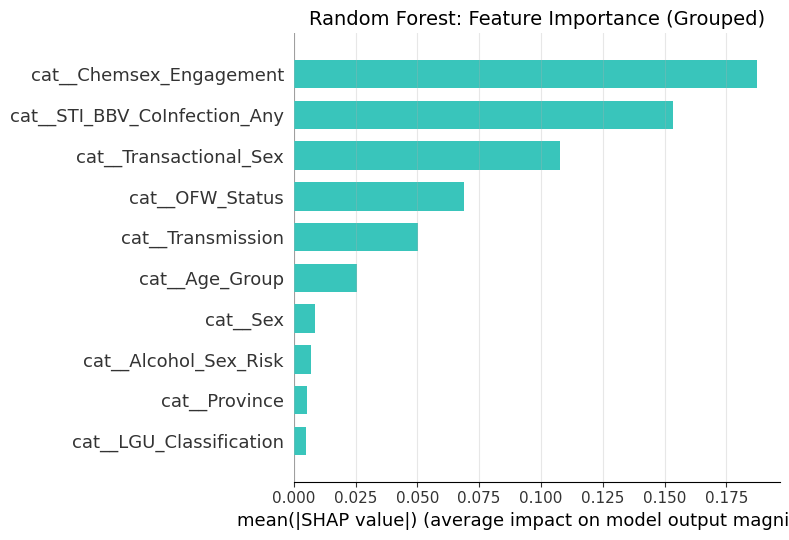

In [81]:
plt.figure(figsize=(10, 8))
plt.title("Random Forest: Feature Importance (Grouped)", fontsize=14)

shap.summary_plot(
    grouped_shap_df_xgb.values,                # The stitched-together SHAP values
    feature_names=grouped_shap_df_xgb.columns, # The clean, grouped category names
    plot_type="bar",
    color="#39C5BB",                          # Miku Teal
    max_display=10,                           # Show top 15 grouped features
    show=False
)

# Adding a subtle grid for readability
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# BEESWARM AND INDIVIDUAL FEATURE IMPORTANCE

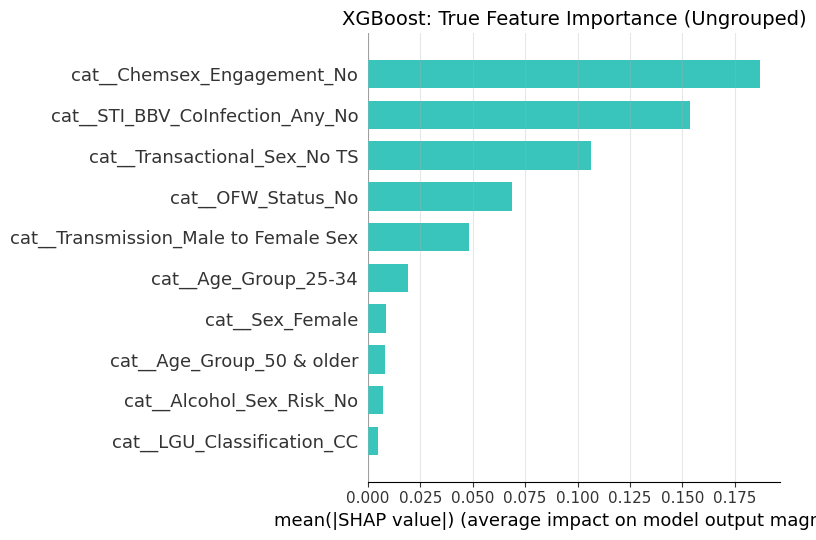

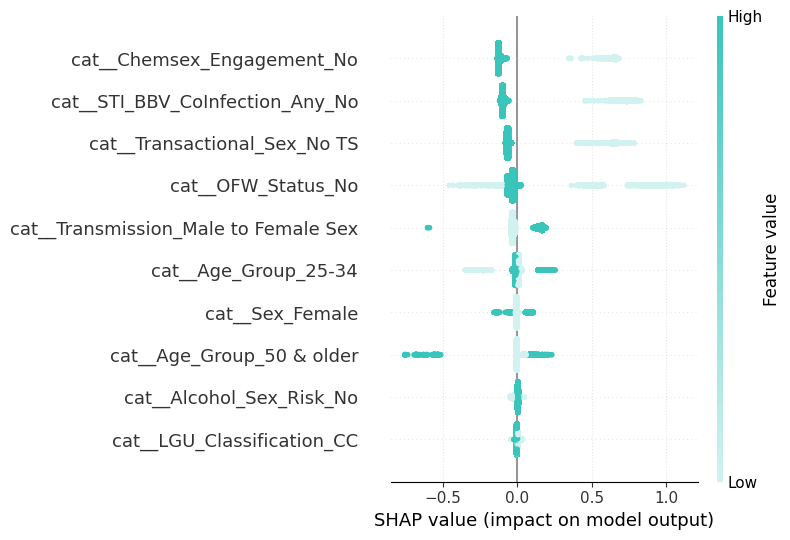

In [72]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap

# ---------------------------------------------------------
# PLOT 1: UNGROUPED GLOBAL IMPORTANCE (BAR PLOT)
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
plt.title("XGBoost: True Feature Importance (Ungrouped)", fontsize=14)

shap.summary_plot(
    shap_raw_xgb,                           # Raw SHAP values
    features=X_test_processed,              # UPDATED: Use the processed 1s and 0s
    feature_names=X_test_processed.columns, # UPDATED: Use the safely cleaned names
    plot_type="bar",
    color="#39C5BB",                        # Miku Teal
    max_display=10,                         # Show top 15 raw features
    show=False
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PLOT 2: UNGROUPED BEESWARM PLOT
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Create the custom Miku gradient
miku_cmap = mcolors.LinearSegmentedColormap.from_list("miku_gradient", ["#D1F2F0", "#39C5BB"])

shap.summary_plot(
    shap_raw_xgb,                           # Raw SHAP values
    features=X_test_processed,              # UPDATED: This applies the 1s and 0s coloring!
    feature_names=X_test_processed.columns, # UPDATED: Use the safely cleaned names
    plot_type="dot",                        # Beeswarm style
    cmap=miku_cmap,
    max_display=10,                         # Match the bar plot
    show=False
)

# Adding a subtle grid
plt.grid(axis='x', color='gray', alpha=0.2, linestyle=':')
plt.tight_layout()
plt.show()

# SAVING THE MODEL (RUN MO TO YA IF YOU THINK MAGANDA RESULT PARA MASAVE)

In [74]:
import joblib

# 1. Save the XGBoost Model itself
best_xgb_model.save_model("best_xgb_imbalanced_model.json")
print("Saved XGBoost model to JSON.")

# 2. Save the ENTIRE Scikit-Learn Preprocessor
joblib.dump(preprocessor, "preprocessor.joblib")
print("Saved ColumnTransformer (One-Hot Encoder) to joblib.")

Saved XGBoost model to JSON.
Saved ColumnTransformer (One-Hot Encoder) to joblib.


# RELOADING

In [75]:
import joblib
import pandas as pd
import xgboost as xgb
import numpy as np

# ---------------------------------------------------------
# STEP 1: LOAD THE PREPROCESSOR AND MODEL
# ---------------------------------------------------------

# 1. Load the Preprocessor (Your One-Hot Encoder)
loaded_preprocessor = joblib.load("preprocessor.joblib")
print("Preprocessor loaded successfully!")

# 2. Load the XGBoost Model
# We initialize an empty XGBClassifier first, then load the saved weights into it
loaded_xgb_model = xgb.XGBClassifier()
loaded_xgb_model.load_model("best_xgb_imbalanced_model.json")
print("XGBoost Model loaded successfully!")


# ---------------------------------------------------------
# STEP 2: INFERENCE (MAKING PREDICTIONS ON NEW DATA)
# ---------------------------------------------------------

# Let's pretend `new_raw_data` is a brand new Pandas DataFrame you just queried.
# It should have the exact same column names as your original `X` (before any processing).
# new_raw_data = pd.read_csv("new_patients.csv") 

def predict_new_data(raw_data, model, preprocessor, threshold=0.5):
    """
    Takes raw data, cleans it, and returns predictions using your golden threshold.
    """
    # A. Transform raw strings into the exact 1s and 0s the model expects
    # Notice we use .transform() here, NOT .fit_transform()!
    processed_arr = preprocessor.transform(raw_data)
    
    # B. Cast it back to a DataFrame with the clean feature names 
    # (Important if you want to run SHAP on the new data later!)
    import re
    feature_names = preprocessor.get_feature_names_out()
    safe_feature_names = [re.sub(r'[\[\]<]', '_', name) for name in feature_names]
    
    X_processed = pd.DataFrame(processed_arr, columns=safe_feature_names, index=raw_data.index)
    
    # C. Get Probabilities
    probabilities = model.predict_proba(X_processed)[:, 1]
    
    # D. Apply your Golden Threshold
    predictions = (probabilities >= threshold).astype(int)
    
    # Create a nice summary dataframe
    results = raw_data.copy()
    results['Probability_Score'] = probabilities
    results['Prediction_Class'] = predictions
    results['Prediction_Label'] = np.where(predictions == 1, 'Reactive', 'Non-Reactive')
    
    return results

# ---------------------------------------------------------
# STEP 3: RUN IT!
# ---------------------------------------------------------

# Insert the exact Golden Threshold you found during your evaluation step
miku_threshold = 0.45 # <-- Update this to your actual calculated threshold

# Run the pipeline! (Uncomment when you have new_raw_data loaded)
# final_predictions_df = predict_new_data(new_raw_data, loaded_xgb_model, loaded_preprocessor, threshold=miku_threshold)
# print(final_predictions_df.head())

Preprocessor loaded successfully!
XGBoost Model loaded successfully!
